# Analisis exploratorio de datos EDA + EVA

Pipeline consolidado: extraccion por lotes, preprocesamiento con 21 features y analisis EVA.

### Estrategia
- **Extraccion por lotes mensuales**: procesa un mes a la vez para manejar 6M+ registros sin saturar RAM.
- **Preprocesamiento consolidado**: 21 features (16 originales + 5 nuevas de la MV).
- **crisis_flag**: scoring EDA >= 5 (mismo que la MV).

### Entradas
- PostgreSQL: tablas creditos, amortizacion, juicios.

### Salidas
- `output/datasets/datos_preprocesados.csv`
- `output/metricas/recomendaciones_eva.csv`
- `output/evidencia_eva/reporte_eva.json`

In [15]:
%load_ext autoreload
%autoreload 2

import gc
import json
import logging
import os
import sys
from datetime import date, datetime

import polars as pl
from sqlalchemy import create_engine

sys.path.insert(0, '..')
from src.eva import Pipeline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [16]:
PATH_SALIDA = "output"
PATH_LOTES = f"{PATH_SALIDA}/lotes"

DB_CONFIG = {
    "host": "localhost",
    "port": "5432",
    "database": "postgres_db",
    "user": "postgres_usr",
    "password": "admin123",
}

ANIO_INICIO = 2005
ANIO_FIN = 2025
MESES_POR_LOTE = 1

for d in ["evidencia_eva", "datasets", "graficas", "metricas", "logs", "lotes"]:
    os.makedirs(f"{PATH_SALIDA}/{d}", exist_ok=True)

logger = logging.getLogger(__name__)
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s",
    handlers=[
        logging.FileHandler(f"{PATH_SALIDA}/logs/eda_{datetime.now().strftime('%Y%m%d_%H%M%S')}.log"),
        logging.StreamHandler(),
    ],
    force=True,
)

connection_string = (
    f"postgresql://{DB_CONFIG['user']}:{DB_CONFIG['password']}"
    f"@{DB_CONFIG['host']}:{DB_CONFIG['port']}/{DB_CONFIG['database']}"
)
engine = create_engine(connection_string)

print("=" * 80)
print("EDA + EVA CONSOLIDADO (POR LOTES)")
print("=" * 80)

EDA + EVA CONSOLIDADO (POR LOTES)


## Utilidades de lotes

In [17]:
def add_months(d: date, months: int) -> date:
    year = d.year + (d.month - 1 + months) // 12
    month = (d.month - 1 + months) % 12 + 1
    return date(year, month, 1)


def iter_windows(start_date: date, end_date: date, step_months: int = 1):
    current = start_date
    while current < end_date:
        nxt = add_months(current, step_months)
        if nxt > end_date:
            nxt = end_date
        yield current, nxt
        current = nxt

In [18]:
def build_query(fecha_inicio: date, fecha_fin: date) -> str:
    return f"""
    SELECT
        mes, riesgo, sector, codigo_sucursal,
        bloque_id,
        num_creditos, monto_total, monto_promedio,
        plazo_promedio, tasa_interes_promedio, saldo_promedio,
        total_costo_judicial, total_gestion_cobro, total_notificaciones,
        tot_dias_mora_promedio, tot_num_moras_promedio, mora_promedio,
        creditos_judiciales, creditos_cerrados, num_clientes_unicos,
        tasa_judicial, tasa_cierre, tasa_mora_90,
        desviacion_montos, coef_variacion_montos, creditos_por_cliente,
        tasa_crecimiento_creditos, tasa_crecimiento_monto,
        crisis_flag
    FROM mv_creditos_mensuales
    WHERE mes >= '{fecha_inicio.isoformat()}'
      AND mes < '{fecha_fin.isoformat()}'
    """


## Preprocesamiento y feature engineering

21 features: 16 originales + 5 nuevas (tasa_mora_90, creditos_por_cliente, coef_variacion_montos, tasa_crecimiento_creditos, tasa_crecimiento_monto).

In [19]:
def preprocesar_datos(df_raw):
    """
    Recibe datos de la MV. Ajusta tipos y ordena.
    La MV ya calcula: agregacion, tasas, 21 features y crisis_flag.
    """
    df = df_raw.clone()

    # Castear columnas Decimal a Float64 para evitar overflow
    for col in df.columns:
        if df[col].dtype == pl.Decimal:
            df = df.with_columns(pl.col(col).cast(pl.Float64))

    df = df.with_columns(pl.col('mes').cast(pl.Date))

    return df.sort(['bloque_id', 'mes'])


## Pipeline principal

In [20]:
def main_eva(modo='notebook'):
    """
    Pipeline consolidado: extraccion por lotes -> preprocesamiento -> growth rates -> EVA.
    """
    logger.info("INICIANDO PIPELINE EDA + EVA CONSOLIDADO")

    import glob
    for f in glob.glob(f"{PATH_LOTES}/features_*.parquet"):
        os.remove(f)
    logger.info("Lotes anteriores limpiados.")

    archivos_lotes = []
    total_raw = 0

    fecha_inicio = date(ANIO_INICIO, 1, 1)
    fecha_fin = date(ANIO_FIN + 1, 1, 1)

    for ini, fin in iter_windows(fecha_inicio, fecha_fin, MESES_POR_LOTE):
        logger.info("Extrayendo lote [%s, %s)", ini, fin)
        query_lote = build_query(ini, fin)

        df_raw = pl.read_database(query=query_lote, connection=engine, infer_schema_length=None)
        n_raw = len(df_raw)
        total_raw += n_raw

        if n_raw == 0:
            del df_raw
            gc.collect()
            continue

        df_feat = preprocesar_datos(df_raw)

        out_parquet = f"{PATH_LOTES}/features_{ini.strftime('%Y%m')}_{fin.strftime('%Y%m')}.parquet"
        df_feat.write_parquet(out_parquet)
        archivos_lotes.append(out_parquet)

        del df_raw, df_feat
        gc.collect()

    if not archivos_lotes:
        raise ValueError("No se generaron lotes con datos.")

    logger.info("Uniendo lotes...")
    df_features = pl.scan_parquet(f"{PATH_LOTES}/features_*.parquet").collect()

    df_features = df_features.sort(['bloque_id', 'mes'])

    dataset_path = f"{PATH_SALIDA}/datasets/datos_preprocesados.csv"
    df_features.write_csv(dataset_path)

    print(f"Dataset: {len(df_features):,} registros, {len(df_features.columns)} columnas")
    dist = df_features['crisis_flag'].value_counts().sort('crisis_flag')
    for row in dist.iter_rows(named=True):
        print(f"  crisis_flag={row['crisis_flag']}: {row['count']:,}")

    logger.info("Ejecutando EVA...")
    pipeline = Pipeline(modo=modo, output_dir=PATH_SALIDA)
    recomendaciones, evidencias = pipeline.run(df_features, target_col='crisis_flag')

    evidencias_path = f"{PATH_SALIDA}/evidencia_eva/reporte_eva.json"
    with open(evidencias_path, "w", encoding="utf-8") as f:
        json.dump({
            "recomendaciones": recomendaciones,
            "evidencias": evidencias,
            "filas_dataset": len(df_features),
            "columnas_dataset": len(df_features.columns),
            "registros_raw_total": total_raw,
            "lotes_procesados": len(archivos_lotes),
            "fecha_generacion": datetime.now().isoformat(),
        }, f, indent=2, ensure_ascii=False, default=str)

    return df_features, recomendaciones

### Ejecutar

2026-07-10 15:10:37,534 - INFO  - INICIANDO PIPELINE EDA + EVA CONSOLIDADO
2026-07-10 15:10:37,535 - INFO  - Lotes anteriores limpiados.
2026-07-10 15:10:37,536 - INFO  - Extrayendo lote [2005-01-01, 2005-02-01)


ANALISIS EDA + EVA CONSOLIDADO
--------------------------------------------------
Autor: omar.velez@yachaytech.edu.ec
Fecha: 2026-07-10 15:10
Rango: 2005 - 2025
--------------------------------------------------


2026-07-10 15:10:37,788 - INFO  - Extrayendo lote [2005-02-01, 2005-03-01)
2026-07-10 15:10:38,022 - INFO  - Extrayendo lote [2005-03-01, 2005-04-01)
2026-07-10 15:10:38,237 - INFO  - Extrayendo lote [2005-04-01, 2005-05-01)
2026-07-10 15:10:38,436 - INFO  - Extrayendo lote [2005-05-01, 2005-06-01)
2026-07-10 15:10:38,638 - INFO  - Extrayendo lote [2005-06-01, 2005-07-01)
2026-07-10 15:10:38,857 - INFO  - Extrayendo lote [2005-07-01, 2005-08-01)
2026-07-10 15:10:39,082 - INFO  - Extrayendo lote [2005-08-01, 2005-09-01)
2026-07-10 15:10:39,300 - INFO  - Extrayendo lote [2005-09-01, 2005-10-01)
2026-07-10 15:10:39,499 - INFO  - Extrayendo lote [2005-10-01, 2005-11-01)
2026-07-10 15:10:39,725 - INFO  - Extrayendo lote [2005-11-01, 2005-12-01)
2026-07-10 15:10:39,933 - INFO  - Extrayendo lote [2005-12-01, 2006-01-01)
2026-07-10 15:10:40,150 - INFO  - Extrayendo lote [2006-01-01, 2006-02-01)
2026-07-10 15:10:40,355 - INFO  - Extrayendo lote [2006-02-01, 2006-03-01)
2026-07-10 15:10:40,660 -

Dataset: 20,025 registros, 29 columnas
  crisis_flag=0: 17,010
  crisis_flag=1: 3,015


2026-07-10 15:11:28,152 - INFO  -      Pearson r=0.3370 (p=0.0000) ✅
2026-07-10 15:11:28,153 - INFO  -      Spearman ρ=0.4031 (p=0.0000) ✅
2026-07-10 15:11:28,154 - INFO  -      Información Mutua=0.0949
2026-07-10 15:11:28,154 - INFO  -      AUC-ROC individual=0.8254 (ALTO)
2026-07-10 15:11:28,155 - INFO  -      Cohen's d=1.0008 (Δmedias=10605704.50)
2026-07-10 15:11:28,155 - INFO  -   ✅ Calidad del dato:
2026-07-10 15:11:28,156 - INFO  -      Completitud=1.0%
2026-07-10 15:11:28,157 - INFO  - 
2026-07-10 15:11:28,157 - INFO  - 📊 ANALIZANDO: monto_promedio
2026-07-10 15:11:28,157 - INFO  - ----------------------------------------
2026-07-10 15:11:28,158 - INFO  -   📊 Distribución:
2026-07-10 15:11:28,163 - INFO  -      Media=4983297.23  Mediana=339257.79  Std=11254731.89
2026-07-10 15:11:28,164 - INFO  -      Skewness=3.87  Kurtosis=20.13  Outliers=15.9%  Nulos=0.0%
2026-07-10 15:11:28,165 - INFO  -      ¿Distribución normal? NO
2026-07-10 15:11:28,166 - INFO  -   🔗 Correlación con cri

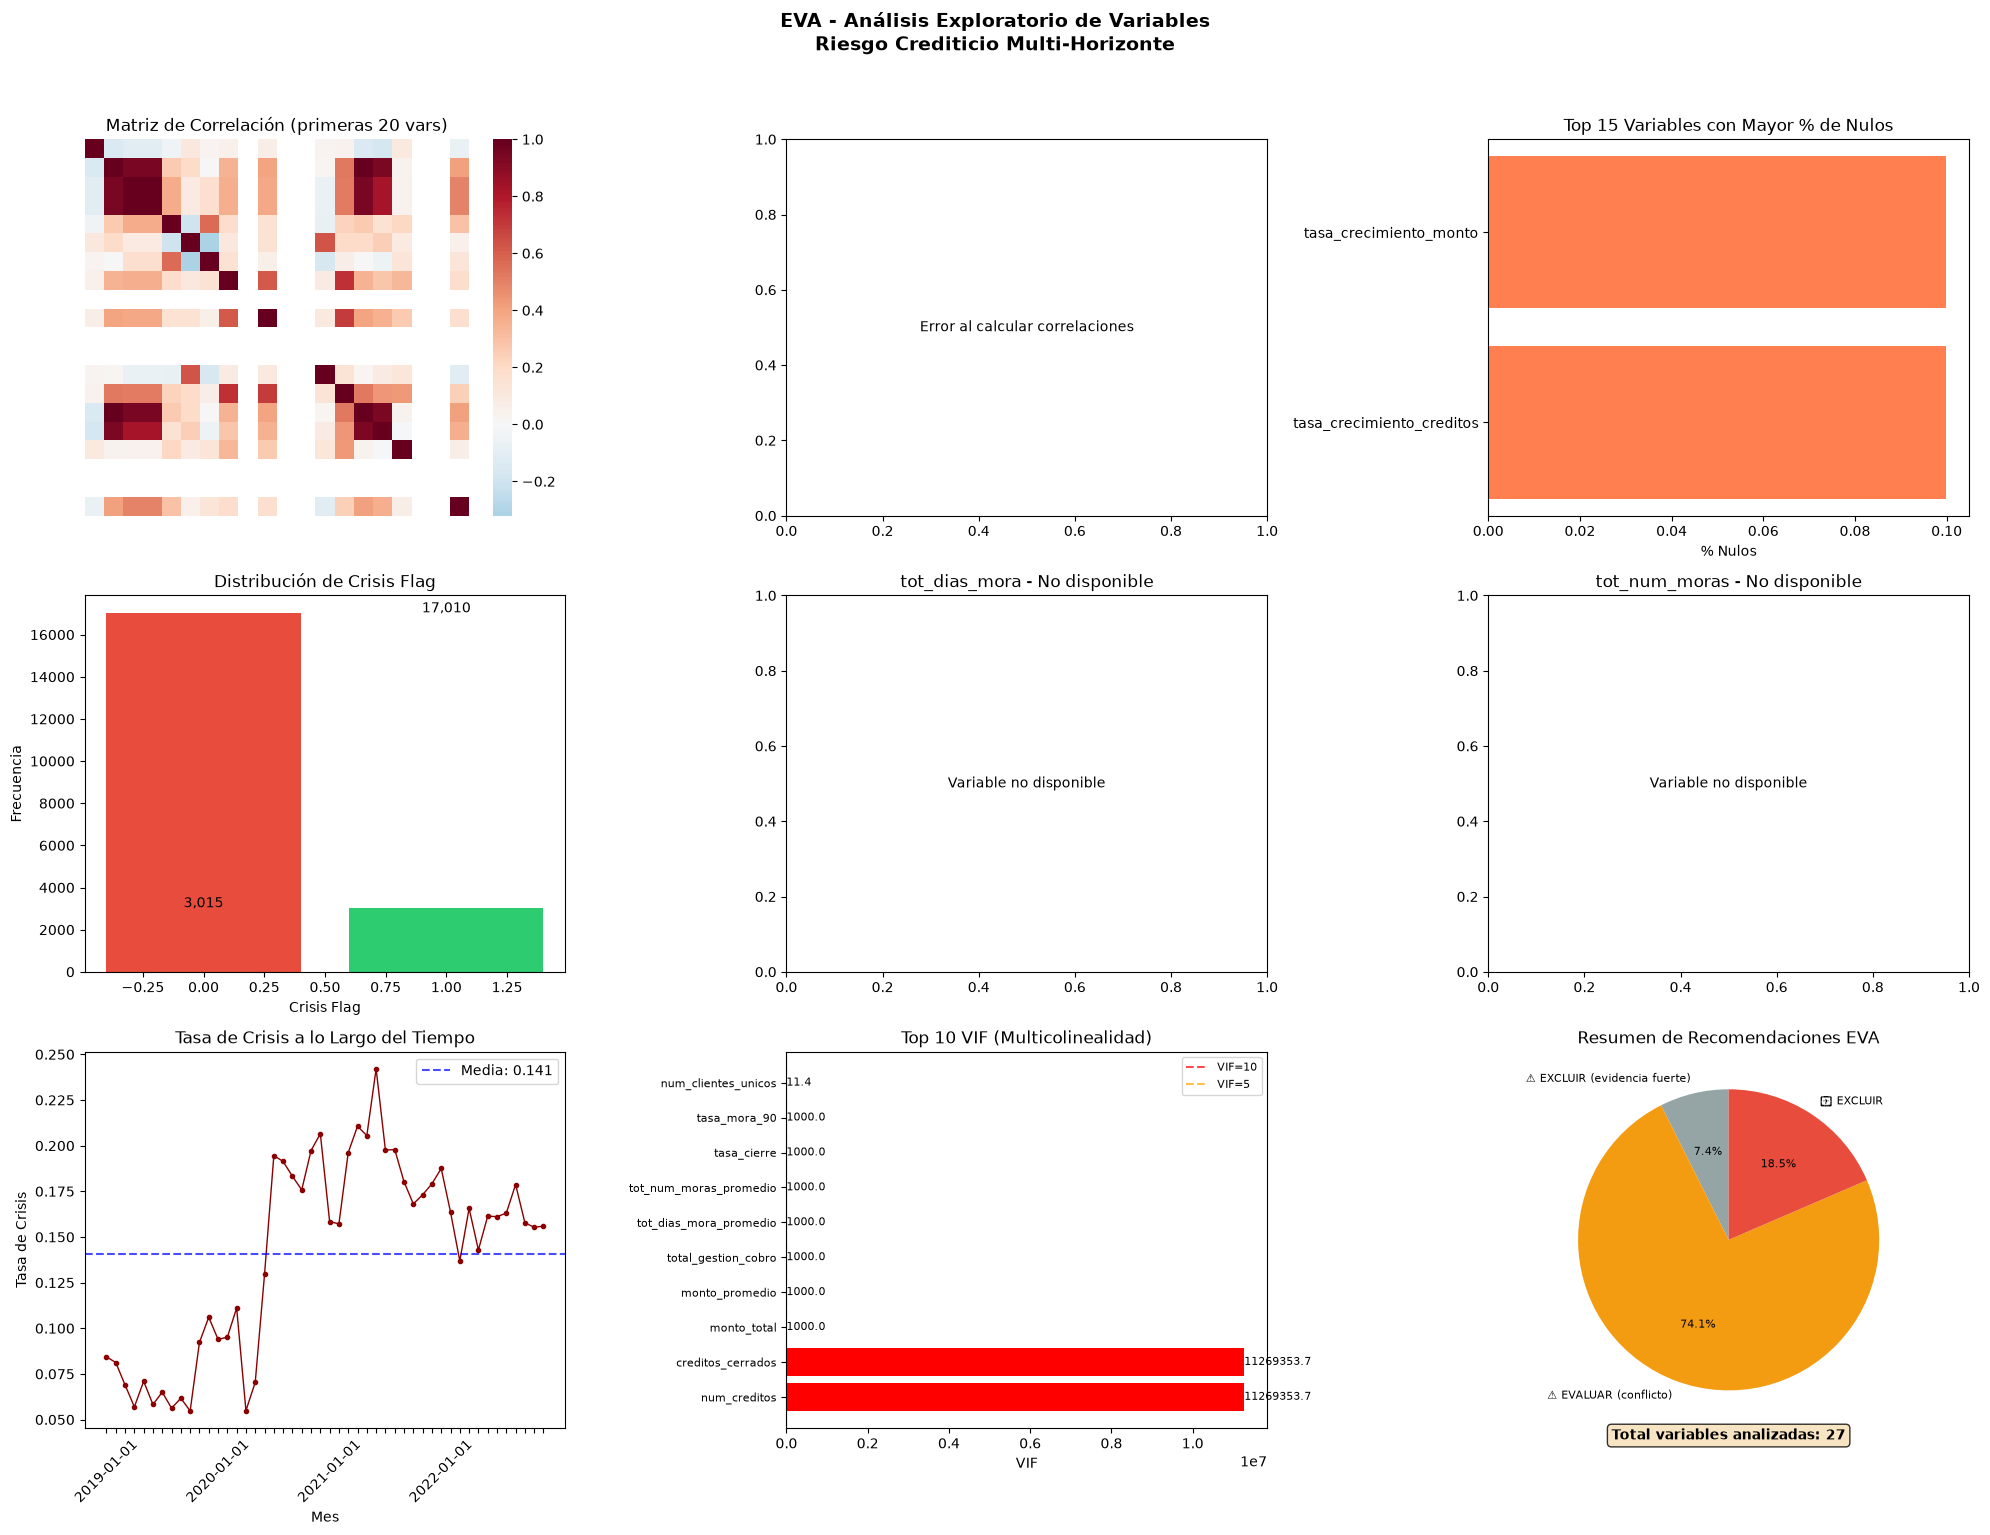

/home/ovelez/Documentos/cursos/Maestria/IADegreeThesis/Desarrollo/noteBooks/../src/eva/pipeline.py:909: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.savefig(png_path, dpi=150, bbox_inches="tight", facecolor="white")
2026-07-10 15:11:32,682 - INFO  - 📊 Dashboard guardado en: output/graficas/eda_completo.png
2026-07-10 15:11:32,684 - INFO  - 📋 Recomendaciones guardadas (27 vars) en: output/metricas/recomendaciones_eva.csv
2026-07-10 15:11:32,684 - INFO  - ✅ EVA COMPLETADO (modo notebook)



PIPELINE COMPLETADO
Salidas:
  1) output/datasets/datos_preprocesados.csv
  2) output/metricas/recomendaciones_eva.csv
  3) output/evidencia_eva/reporte_eva.json


In [21]:
print("ANALISIS EDA + EVA CONSOLIDADO")
print("-" * 50)
print("Autor: omar.velez@yachaytech.edu.ec")
print(f"Fecha: {datetime.now().strftime('%Y-%m-%d %H:%M')}")
print(f"Rango: {ANIO_INICIO} - {ANIO_FIN}")
print("-" * 50)

df_features, recomendaciones = main_eva()

print("\nPIPELINE COMPLETADO")
print("Salidas:")
print(f"  1) {PATH_SALIDA}/datasets/datos_preprocesados.csv")
print(f"  2) {PATH_SALIDA}/metricas/recomendaciones_eva.csv")
print(f"  3) {PATH_SALIDA}/evidencia_eva/reporte_eva.json")

![icon](../../DocumentosBase/yachayCuadrado.jpg)<br/>***<omar.velez@yachaytech.edu.ec>***<br/>*julio 2026*